In [1]:
import matplotlib.pyplot as plt
import torch
import torchvision
from torch import nn
from torchvision import transforms, datasets
from torchinfo import summary
from torch.utils.data import DataLoader, Subset

In [4]:
if torch.cuda.is_available():
    device = "cuda" # Use NVIDIA GPU 
else:
    device = "cpu"
device

'cpu'

In [16]:
# Veriyi Colab/bilgisayarına indirmesi ve başlatması için:
data = datasets.Imagenette(root="./data", split="train", download=True, size="320px")

100%|██████████| 342M/342M [04:23<00:00, 1.30MB/s]   


Extracting ./data\imagenette2-320.tgz to ./data


In [17]:
len(data)

9469

In [47]:
img, label = data[3131]

In [48]:
label

3

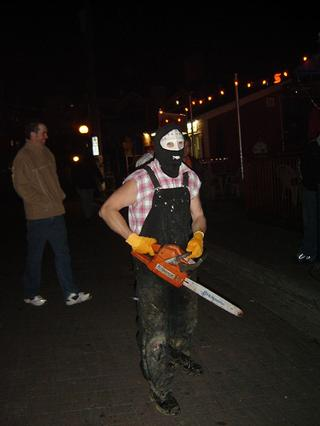

In [46]:
img

In [31]:
img.size

(320, 426)

In [53]:
class Fire(nn.Module):
    def __init__(self, in_channels = 3, s1 = 16, e1 = 64, e3 = 64):
        super().__init__()
        self.squeeze = nn.Conv2d(
            in_channels = in_channels,
            out_channels = s1,
            kernel_size = 1,
            padding = 0
            )
        self.activation = nn.ReLU(inplace = True)

        self.expand1 = nn.Conv2d(in_channels = s1,
                                out_channels = e1,
                                kernel_size = 1,
                                padding = 0)
        
        self.expand3 = nn.Conv2d(in_channels = s1,
                                out_channels = e3,
                                kernel_size = 3,
                                padding = 1)
    def forward(self, x):
        squeeze_out = self.activation(self.squeeze(x))

        out_e1 = self.activation(self.expand1(squeeze_out))
        out_e3 = self.activation(self.expand3(squeeze_out))

        return torch.cat([out_e1, out_e3], dim = 1)

In [55]:
class SqueezeNet(nn.Module):
    def __init__(self, classes = 10):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels = 3, 
                                out_channels = 96,
                                kernel_size = 7, 
                                stride = 2, 
                                padding = 3)
        self.relu1 = nn.ReLU(inplace=True)
        self.maxpool1 = nn.MaxPool2d(3, stride = 2)
        
        self.fire2 = Fire(in_channels = 96, s1 = 16, e1 = 64, e3 = 64)
        self.fire3 = Fire(in_channels = 128, s1 = 16, e1 = 64, e3 = 64)
        self.fire4 = Fire(in_channels = 128, s1 = 32, e1 = 128, e3 = 128)
        self.maxpool4 = nn.MaxPool2d(3, stride = 2)

        self.fire5 = Fire(in_channels = 256, s1 = 32, e1 = 128, e3 = 128)
        self.fire6 = Fire(in_channels = 256, s1 = 48, e1 = 192, e3 = 192)
        self.fire7 = Fire(in_channels = 384, s1 = 48, e1 = 192, e3 = 192)
        self.fire8 = Fire(in_channels = 384, s1 = 64, e1 = 256, e3 = 256)
        self.maxpool8 = nn.MaxPool2d(3, stride = 2)

        self.fire9 = Fire(in_channels = 512, s1 = 64, e1 = 256, e3 = 256)

        self.dropout =nn.Dropout(p=0.5)
        
        self.conv10 = nn.Conv2d(in_channels = 512, 
                                out_channels = classes,
                                kernel_size = 1, 
                                stride = 1)
        self.relu10 = nn.ReLU(inplace = True)
        self.avgpool10 = nn.AdaptiveAvgPool2d((1, 1))

    def forward(self, x):
        first = self.maxpool1(self.relu1(self.conv1(x)))
        blok_1 = self.maxpool4(self.fire4(self.fire3(self.fire2(first))))
        blok_2 = self.maxpool8(self.fire8(self.fire7(self.fire6(self.fire5(blok_1)))))
        blok_3 = self.avgpool10(self.relu10(self.conv10(self.dropout(self.fire9(blok_2)))))  # batch,10,1,1
        return torch.flatten(blok_3, 1)  # (batch,10) 0. indekse dokunma flattena 1den başla